<a href="https://colab.research.google.com/github/smchakma/ResearchWithSkillMoprh/blob/main/Data_Processing_c6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

sb.set_theme(style='whitegrid', palette = 'Set2')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets/agriculture_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.head()

,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [5]:
df.describe()

,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters)
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,254.963800,4.905400,2.398000,27.059200,56724.295600
std,139.417782,2.732689,1.438613,13.345789,27264.992053
min,12.500000,0.500000,0.140000,3.860000,5869.750000
25%,135.710000,2.437500,0.972500,16.190000,37818.152500
50%,281.980000,5.045000,2.330000,28.970000,54097.075000
75%,368.107500,6.885000,3.417500,37.860000,82240.032500
max,483.880000,9.960000,4.990000,48.020000,94754.730000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


In [7]:
print(df.isnull().sum().sum())

0


In [8]:
np.random.seed(42)
# Define 'inject' with columns and the number of NaN values to inject
inject = {'Farm_Area(acres)': 5, 'Fertilizer_Used(tons)': 5, 'Soil_Type': 3, 'Water_Usage(cubic meters)': 3}

for col, n in inject.items():
  idx = np.random.choice(df.index, size=n, replace=False)
  df.loc[idx, col] = np.nan

df.isnull().sum()[df.isnull().sum() > 0]

,0
Farm_Area(acres),5
Fertilizer_Used(tons),5
Soil_Type,3
Water_Usage(cubic meters),3


In [9]:
##Fill the Misasing value


df['Farm_Area(acres)'].fillna(df['Farm_Area(acres)'].median(), inplace=True)
df['Fertilizer_Used(tons)'].fillna(df['Fertilizer_Used(tons)'].mean(), inplace=True)
df['Water_Usage(cubic meters)'].fillna(df['Water_Usage(cubic meters)'].median(), inplace=True)
df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

df.isnull().sum().sum()

np.int64(0)

In [10]:
##remove duplicates value


df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape} ")


Shape after removing duplicates: (50, 10) 


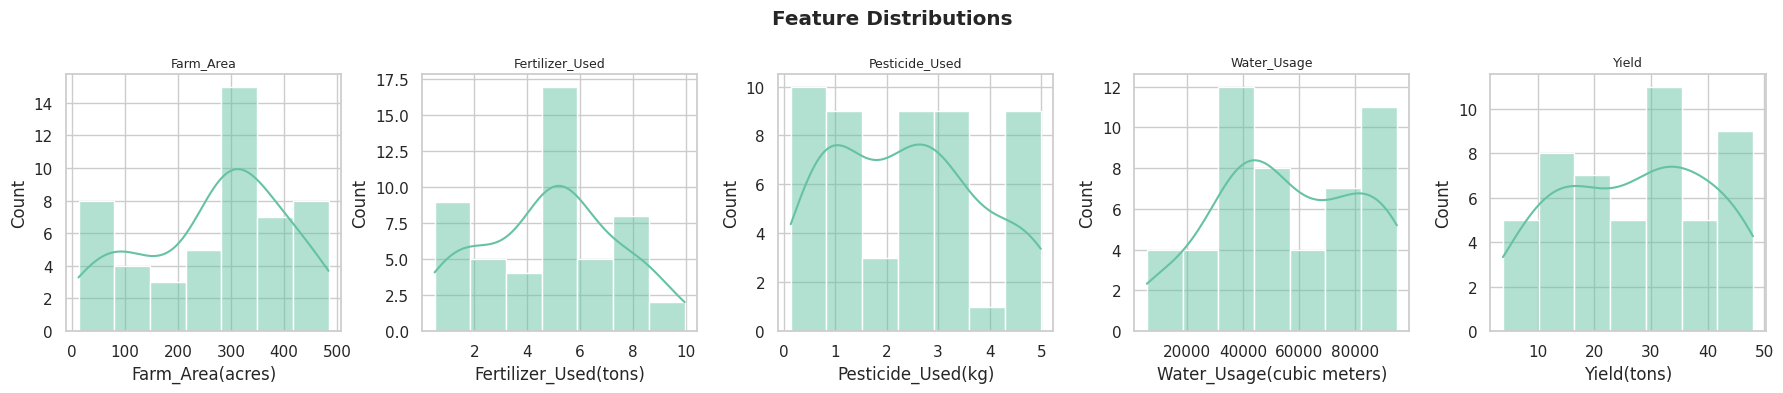

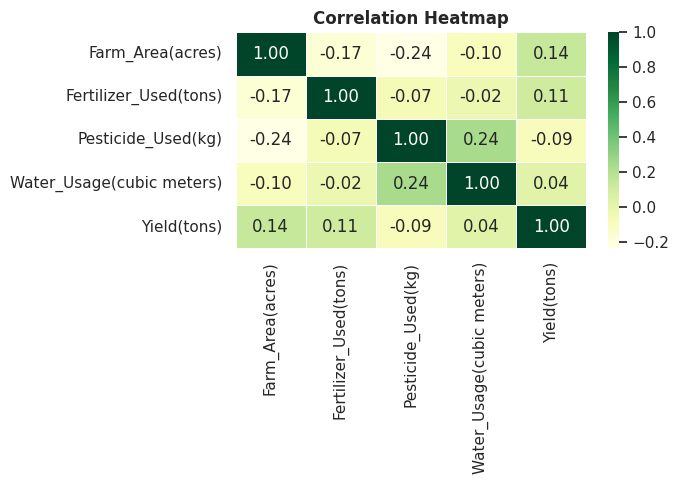

In [19]:
num_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)' ,'Water_Usage(cubic meters)', 'Yield(tons)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
  sb.histplot(df[col], ax=ax, kde=True)
  ax.set_title(col.split('(')[0], fontsize=9)

plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sb.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()